<a href="https://colab.research.google.com/github/techasit239/Dads-5001/blob/code/car_accident_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
import IPython
from IPython.display import display, Image
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#(1) Thailand Accident Introduction

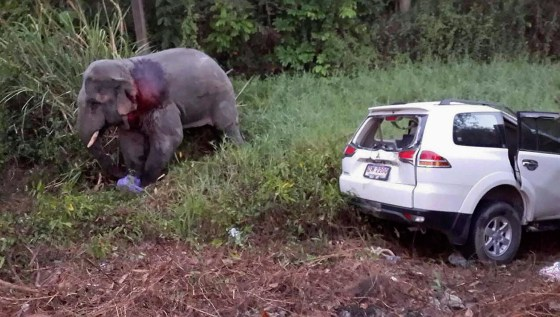

In [ ]:
display(Image("https://media-cldnry.s-nbcnews.com/image/upload/t_fit-560w,f_auto,q_auto:best/newscms/2014_11/246306/pb-140312-elephant-01.jpg"))

#(2) Dataset Exploration : Cleansing & Transformation

##|- 2.1 Look around dataset overview

In [ ]:
df_car = pd.read_csv("/content/thai_road_accident_2019_2022.csv")
display( df_car.head(3) )
display( df_car.tail(3) )

,acc_code,incident_datetime,report_datetime,province_th,province_en,agency,route,vehicle_type,presumed_cause,accident_type,number_of_vehicles_involved,number_of_fatalities,number_of_injuries,weather_condition,latitude,longitude,road_description,slope_description
0,571905,1/1/2019 0:00,2/1/2019 6:11,ลพบุรี,Loburi,department of rural roads,แยกทางหลวงหมายเลข 21 (กม.ที่ 31+000) - บ้านวัง...,motorcycle,driving under the influence of alcohol,other,1,0,2,clear,14.959105,100.873463,straight road,no slope
1,3790870,1/1/2019 0:03,20/2/2020 13:48,อุบลราชธานี,Ubon Ratchathani,department of highways,เดชอุดม - อุบลราชธานี,private/passenger car,speeding,rollover/fallen on straight road,1,0,2,clear,15.210738,104.862689,straight road,no slope
2,599075,1/1/2019 0:05,1/1/2019 10:35,ประจวบคีรีขันธ์,Prachuap Khiri Khan,department of highways,ปราณบุรี - ปากน้ำปราณ,motorcycle,speeding,head-on collision (not overtaking),2,1,0,clear,12.374259,99.907949,wide curve,slope area


,acc_code,incident_datetime,report_datetime,province_th,province_en,agency,route,vehicle_type,presumed_cause,accident_type,number_of_vehicles_involved,number_of_fatalities,number_of_injuries,weather_condition,latitude,longitude,road_description,slope_description
81732,7567022,31/12/2022 23:30,23/1/2023 9:17,มหาสารคาม,Maha Sarakham,department of highways,วาปีปทุม - พยัคฆภูมิพิสัย,van,speeding,rollover/fallen on straight road,1,0,3,clear,15.657933,103.253294,straight road,no slope
81733,7531271,31/12/2022 23:45,1/1/2023 5:36,กำแพงเพชร,Kamphaeng Phet,department of highways,นครชุม - มอเจริญ,motorcycle,driving under the influence of alcohol,rollover/fallen on straight road,1,1,0,clear,16.439598,99.423104,straight road,no slope
81734,7556715,31/12/2022 23:55,11/1/2023 14:50,เชียงราย,Chiang Rai,department of highways,แยกแม่กรณ์ - ห้วยพลู,private/passenger car,speeding,rear-end collision,2,3,0,clear,19.943224,99.846455,straight road,no slope


In [ ]:
# Explore dataset 'quality and dimension
display( f"(rows, cols) : {df_car.shape}")
display("="*55)
display( df_car.info() )
display( df_car.nunique() )

'(rows, cols) : (81735, 18)'

'======================================================='

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81735 entries, 0 to 81734
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   acc_code                     81735 non-null  int64  
 1   incident_datetime            81735 non-null  object 
 2   report_datetime              81735 non-null  object 
 3   province_th                  81735 non-null  object 
 4   province_en                  81735 non-null  object 
 5   agency                       81735 non-null  object 
 6   route                        81735 non-null  object 
 7   vehicle_type                 81735 non-null  object 
 8   presumed_cause               81735 non-null  object 
 9   accident_type                81735 non-null  object 
 10  number_of_vehicles_involved  81735 non-null  int64  
 11  number_of_fatalities         81735 non-null  int64  
 12  number_of_injuries           81735 non-null  int64  
 13  weather_conditio

None

,0
acc_code,81735
incident_datetime,67917
report_datetime,66234
province_th,78
province_en,78
agency,3
route,3882
vehicle_type,15
presumed_cause,54
accident_type,11


In [ ]:
df_car["incident_datetime"] = pd.to_datetime(df_car["incident_datetime"], format="%d/%m/%Y %H:%M")
df_car["report_datetime"] = pd.to_datetime(df_car["report_datetime"], format="%d/%m/%Y %H:%M")
display(df_car.head(3))
display(df_car.info())

,acc_code,incident_datetime,report_datetime,province_th,province_en,agency,route,vehicle_type,presumed_cause,accident_type,number_of_vehicles_involved,number_of_fatalities,number_of_injuries,weather_condition,latitude,longitude,road_description,slope_description
0,571905,2019-01-01 00:00:00,2019-01-02 06:11:00,ลพบุรี,Loburi,department of rural roads,แยกทางหลวงหมายเลข 21 (กม.ที่ 31+000) - บ้านวัง...,motorcycle,driving under the influence of alcohol,other,1,0,2,clear,14.959105,100.873463,straight road,no slope
1,3790870,2019-01-01 00:03:00,2020-02-20 13:48:00,อุบลราชธานี,Ubon Ratchathani,department of highways,เดชอุดม - อุบลราชธานี,private/passenger car,speeding,rollover/fallen on straight road,1,0,2,clear,15.210738,104.862689,straight road,no slope
2,599075,2019-01-01 00:05:00,2019-01-01 10:35:00,ประจวบคีรีขันธ์,Prachuap Khiri Khan,department of highways,ปราณบุรี - ปากน้ำปราณ,motorcycle,speeding,head-on collision (not overtaking),2,1,0,clear,12.374259,99.907949,wide curve,slope area


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81735 entries, 0 to 81734
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   acc_code                     81735 non-null  int64         
 1   incident_datetime            81735 non-null  datetime64[ns]
 2   report_datetime              81735 non-null  datetime64[ns]
 3   province_th                  81735 non-null  object        
 4   province_en                  81735 non-null  object        
 5   agency                       81735 non-null  object        
 6   route                        81735 non-null  object        
 7   vehicle_type                 81735 non-null  object        
 8   presumed_cause               81735 non-null  object        
 9   accident_type                81735 non-null  object        
 10  number_of_vehicles_involved  81735 non-null  int64         
 11  number_of_fatalities         81735 non-nu

None

# (3) Dataset Exploration : Data Summarization & Visualization

##|- 3.1 Overview & Trend

###Total Accident & %Growth by incident year

In [ ]:
df = df_car.loc[:, ["acc_code","incident_datetime","province_th"]]
df = df.assign(
    incident_date = lambda x:x["incident_datetime"].dt.date,
    incident_mo_day = lambda x:x["incident_datetime"].dt.strftime("%m-%d"),
    incident_yr = lambda x: x["incident_datetime"].dt.year,
    incident_mo = lambda x: x["incident_datetime"].dt.month,
    incident_day = lambda x: x["incident_datetime"].dt.day,
    incident_mo_name = lambda x:x["incident_datetime"].dt.month_name(),
    incident_day_name = lambda x:x["incident_datetime"].dt.day_name(),
    incident_hour = lambda x:x["incident_datetime"].dt.hour,
    incident_day_night = lambda x:np.where(
        (x["incident_datetime"].dt.hour>=6) & (x["incident_datetime"].dt.hour<=18),"Day","Night")
)
display(df.head(3))
display(df.tail(3))
display(df.loc[:,["acc_code","incident_hour","incident_day_night"]].groupby(["incident_hour","incident_day_night"]).agg("count"))

,acc_code,incident_datetime,province_th,incident_date,incident_mo_day,incident_yr,incident_mo,incident_day,incident_mo_name,incident_day_name,incident_hour,incident_day_night
0,571905,2019-01-01 00:00:00,ลพบุรี,2019-01-01,01-01,2019,1,1,January,Tuesday,0,Night
1,3790870,2019-01-01 00:03:00,อุบลราชธานี,2019-01-01,01-01,2019,1,1,January,Tuesday,0,Night
2,599075,2019-01-01 00:05:00,ประจวบคีรีขันธ์,2019-01-01,01-01,2019,1,1,January,Tuesday,0,Night


,acc_code,incident_datetime,province_th,incident_date,incident_mo_day,incident_yr,incident_mo,incident_day,incident_mo_name,incident_day_name,incident_hour,incident_day_night
81732,7567022,2022-12-31 23:30:00,มหาสารคาม,2022-12-31,12-31,2022,12,31,December,Saturday,23,Night
81733,7531271,2022-12-31 23:45:00,กำแพงเพชร,2022-12-31,12-31,2022,12,31,December,Saturday,23,Night
81734,7556715,2022-12-31 23:55:00,เชียงราย,2022-12-31,12-31,2022,12,31,December,Saturday,23,Night


,,acc_code
incident_hour,incident_day_night,
0,Night,2590
1,Night,2635
2,Night,2354
3,Night,2125
4,Night,2227
5,Night,2436
6,Day,2528
7,Day,3483
8,Day,3684


In [ ]:
# Total Accident & %Growth by incident year, month, ...
pivot = df.pivot_table(columns="incident_yr",values="acc_code",aggfunc="count").rename({"acc_code":"acc_count"})
pivot
growth = pivot.pct_change(axis=1).rename(index={"acc_count": "%acc_growth"})
growth

def max_negative_color(val, attr=""):
  return (np.where(val==np.nanmax(val.values),attr,""))

# concat
pivot = pd.concat([pivot, growth])
pivot.loc[["%acc_growth"],:] = pivot.loc[["%acc_growth"],:].agg( lambda v:v*100 )
# style
s1 = pivot.style.format(formatter="{:,.0f}", na_rep=0, subset=pd.IndexSlice[["acc_count"],:]) \
  .format(formatter="{:,.2f}", na_rep=0, subset=pd.IndexSlice[["%acc_growth"],:]) \
  .apply(max_negative_color, attr="color:red;font-weight:bold", axis=1)
display(s1)

# graph
plt.figure(figsize=(15,5), dpi=1200)
fig, ax = plt.subplots(figsize=(15,5), dpi=1200)

ax = pivot.loc[["acc_count"]].T.plot(kind="bar", ax=ax)
ax.set_title("Total accident by year", fontsize=18, fontweight="bold")
ax.set_ylabel("Number of accident")
ax.set_xlabel("Incident year")
plt.xticks(rotation=0)
for container in ax.containers:
  ax.bar_label(container, fmt="%.0f")
plt.show()


incident_yr,2019,2020,2021,2022
acc_count,"19,194","21,052","20,457","21,032"
%acc_growth,0,9.68,-2.83,2.81


<Figure size 18000x6000 with 0 Axes>

In [ ]:
# Total Accident & %Growth by incident year, month, ...
# grouped = df.groupby(["incident_date", "incident_yr"]).agg({"acc_code": "count"}).rename(index={"acc_code":"acc_count"})
grouped = df.pivot_table(index="incident_mo_day", columns="incident_yr", values="acc_code", aggfunc="count")
# display(grouped)

fig, ax = plt.subplots(4, 1, figsize=(15,5), dpi=1200, sharex = True)
years = grouped.columns
for a, y in zip(ax, years):
  grouped[y].plot(ax=a)
  a.set_title(f"No. of accident trend in {y}")
  a.set_ylim(0, 500)
  plt.subplots_adjust(hspace=1)

# ax = grouped["acc_code"].plot(ax=ax, x="incident_date", y="acc_count", kind="line", subplots=)
# plt.show()

##|- 3.2 Questions

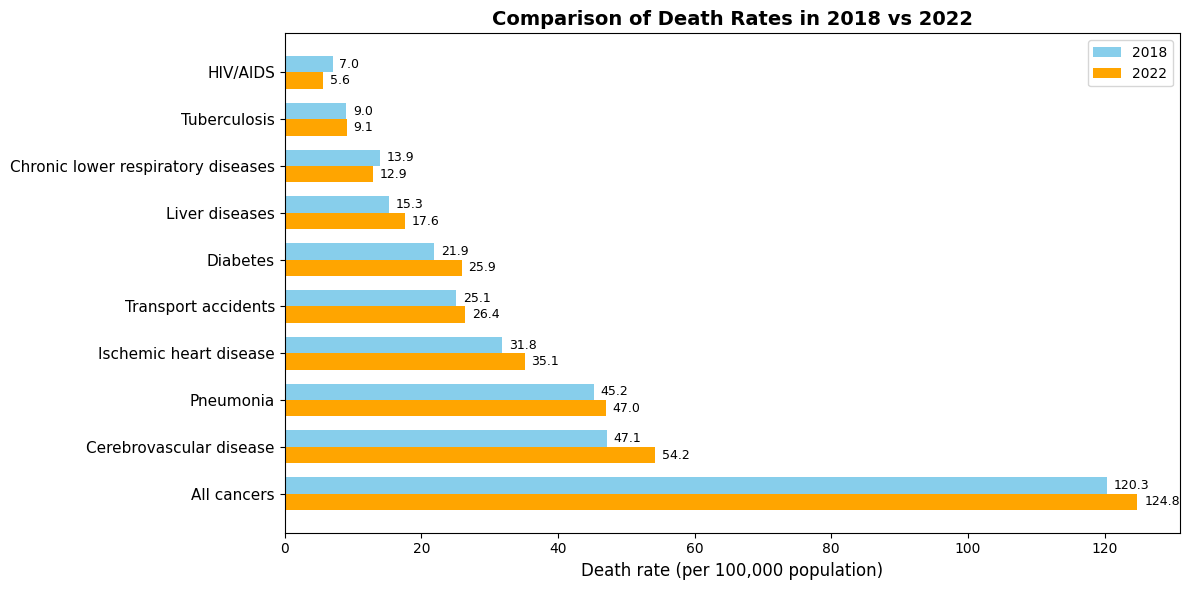

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Data
causes = [
    "HIV/AIDS",
    "Tuberculosis",
    "Chronic lower respiratory diseases",
    "Liver diseases",
    "Diabetes",
    "Transport accidents",
    "Ischemic heart disease",
    "Pneumonia",
    "Cerebrovascular disease",
    "All cancers",
]
rate_2018 = [7, 9, 13.9, 15.3, 21.9, 25.1, 31.8, 45.2, 47.1, 120.3]
rate_2022 = [5.6, 9.1, 12.9, 17.6, 25.9, 26.4, 35.1, 47.0, 54.2, 124.8]

# Y positions
y = np.arange(len(causes))
h = 0.35

# Plot
plt.figure(figsize=(12, 6))
bars1 = plt.barh(y - h/2, rate_2018, height=h, label="2018", color="skyblue")
bars2 = plt.barh(y + h/2, rate_2022, height=h, label="2022", color="orange")

# Add text labels on bars
for bar in bars1:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center", fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center", fontsize=9
    )


plt.yticks(y, causes, fontsize=11)
plt.xlabel("Death rate (per 100,000 population)", fontsize=12)
plt.title("Comparison of Death Rates in 2018 vs 2022", fontsize=14, fontweight="bold")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
